# Введение

В статье приводится краткий обзор продвинутых техник промпт-инжиниринга (составления запросов к LLM - ChatGPT, DeepSek, Qwen, Шедеврум и т д). Продвинутый промптинг - процесс итеративный, требующий некоторого количества экспериментов. Также стоит упомянуть, что у каждой LLM есть нюансы в интерпретации промптов, поэтому тонкую настройку приходится осваивать заново при переходе к новой модели. Ну а для тех, кто умеет разворачивать разные LLM, может быть полезен калькулятор ресурсов https://huggingface.co/docs/accelerate/main/en/usage_guides/model_size_estimator

**Риски использования LLM**

Как у любого инструмента, у LLM есть свои риски и ограничения в использовании.
    
    Галлюцинации. Модели обычно настроены на то, чтобы «нравиться» человеку, создавать вполне связные и последовательные ответы. Но не всегда у модели есть нужный объем информации и не всегда она может оценить, насколько корректен ее ответ с точки зрения фактов и реальности. Соответственно, в некоторых случаях LLM начинают «додумывать» то, чего нет на самом деле. 

    Предубеждения/Смещения. Учитывая, что LLM обычно учатся на гигантских объемах данных, собранных в интернете, модели могут «впитывать» те предубеждения или смещения в оценке ситуации, которые есть в нашем информационном поле. Например, модель может повторять увиденные ею гендерные или расовые предубеждения. 

    Утечка данных. В случае использованиях внешних решений всегда есть некоторый риск утечки данных, связанный с тем, что данные взаимодействия пользователя с LLM могут быть использованы при обновлении информации, доступной модели. То есть в случае внесения критичной коммерческой или персональной информации эти данные могут стать доступны любому желающему.


# Основы

**Примеры решаемых задач**

    ответ на вопрос на основе общих знаний/по предложенному контексту

    генерация идей/креативного контента/кода/промптов
    
    моделирование ситуаций/оценка контента
    
    суммаризация текста/объяснение текста или кода/проверка грамматики/изменение стиля/
    
    структурирование данных/классификация/Разметка данных средствами LLM/выделение именованных сущностей
    
    поддержание диалога
    
    перевод на другой язык

**Формат промпта, который предлагают разработчики модели Gemini от Google:**

        Роль - определите, "кем" должна быть модель. В каком тоне и стиле она должна отвечать.

        Задача - четко сформулируйте задачу или вопрос

        Контекст - предоставьте необходимый контекст. Также важно помнить, что некоторые модели (к ним относится ChatGPT) используют предыдущий диалог как контекст для каждого следующего запроса.

        Формат, Границы - укажите формат, тон и длину ответа, установите явные границы для содержимого

        Примеры - включите как положительные, так и отрицательные примеры, если это применимо
        
Эти куски можно переставлять, убирать и добавлять новые (Тон, критерии и т д). Пример https://prompt1.ru/listing/prompt-dlja-programmistov-universalnoe-sozdanie-koda/

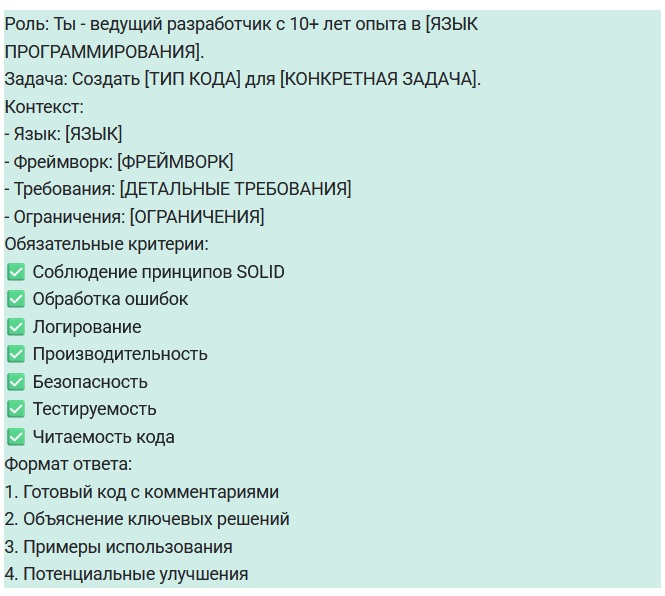

In [1]:
from IPython.display import Image
Image('Ex_1.jpg', width=300, height=150 )

**Общие рекомендации**

Что НЕ стоит делать:

    Давать неясные инструкции (получим слишком общие ответы). Давать слишком подробные инструкции (модель начинает путаться или игнорировать некоторые инструкции). Предполагать, что модель понимает, говорить образно (Модель всегда интерпретирует буквально). Противоречить самому себе.
    
**Пример:**    

https://t.me/devsoulart/4497?single

Поэкспериментируем с промптом в Шедевруме

Слева fantasy tree, graceful woman near sailboat, glowing seascape, textured oil paint, luminescent sky, romantic surrealism, iridescent surface, dreamy tone

Справа fantasy tree, graceful woman near sailboat, glowing seascape, textured oil paint, dreamy tone

Половину промпта можно тупо выбросить без ощутимого влияния на результат. Освободившееся место можно потратить на что-то полезное, например, сделать паруса алыми)

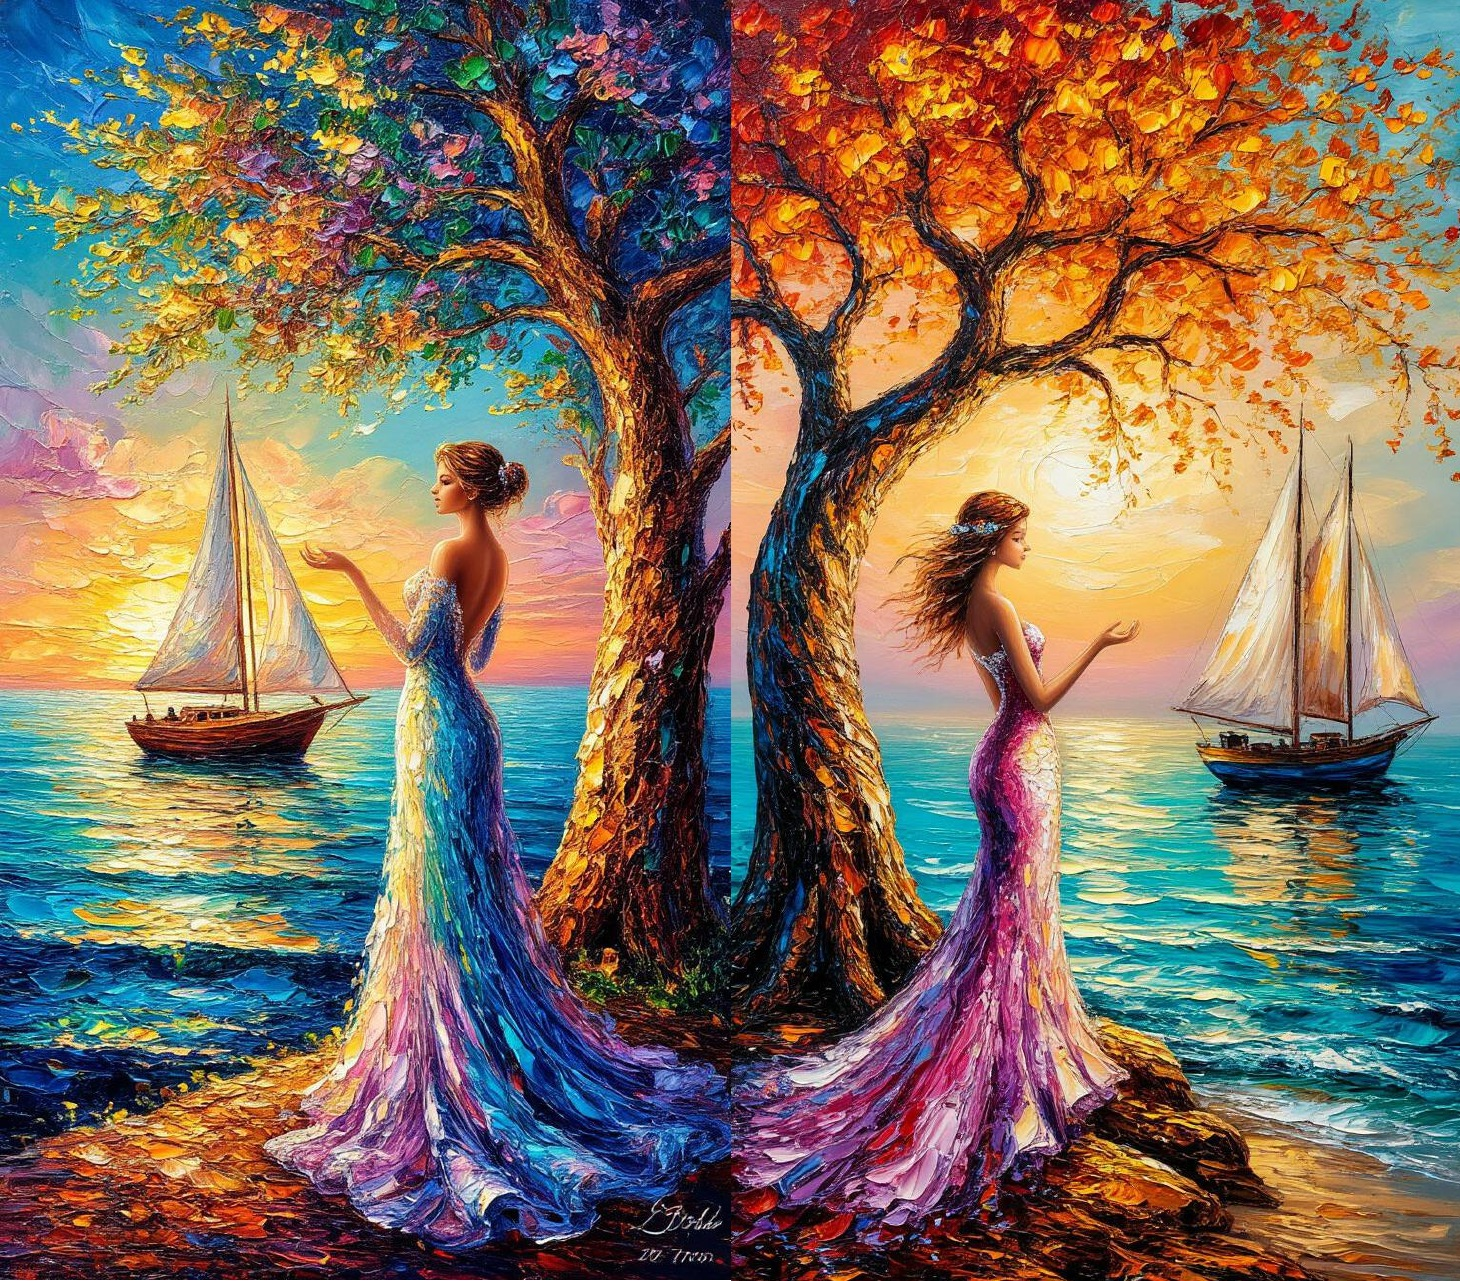

In [3]:
from IPython.display import Image
Image('Ex_2.jpg', width=600, height=150 )

**Пример 2**

40 y.o. Rick , blue hair, white lab coat, as a StarCraft character. Сидит в лаборатории, паяет девайс, металлические манипуляторы. Artstation style

удаление фразы "металлические манипуляторы" (справа) делает рисунки в целом более реалистичными и менее Artstation style

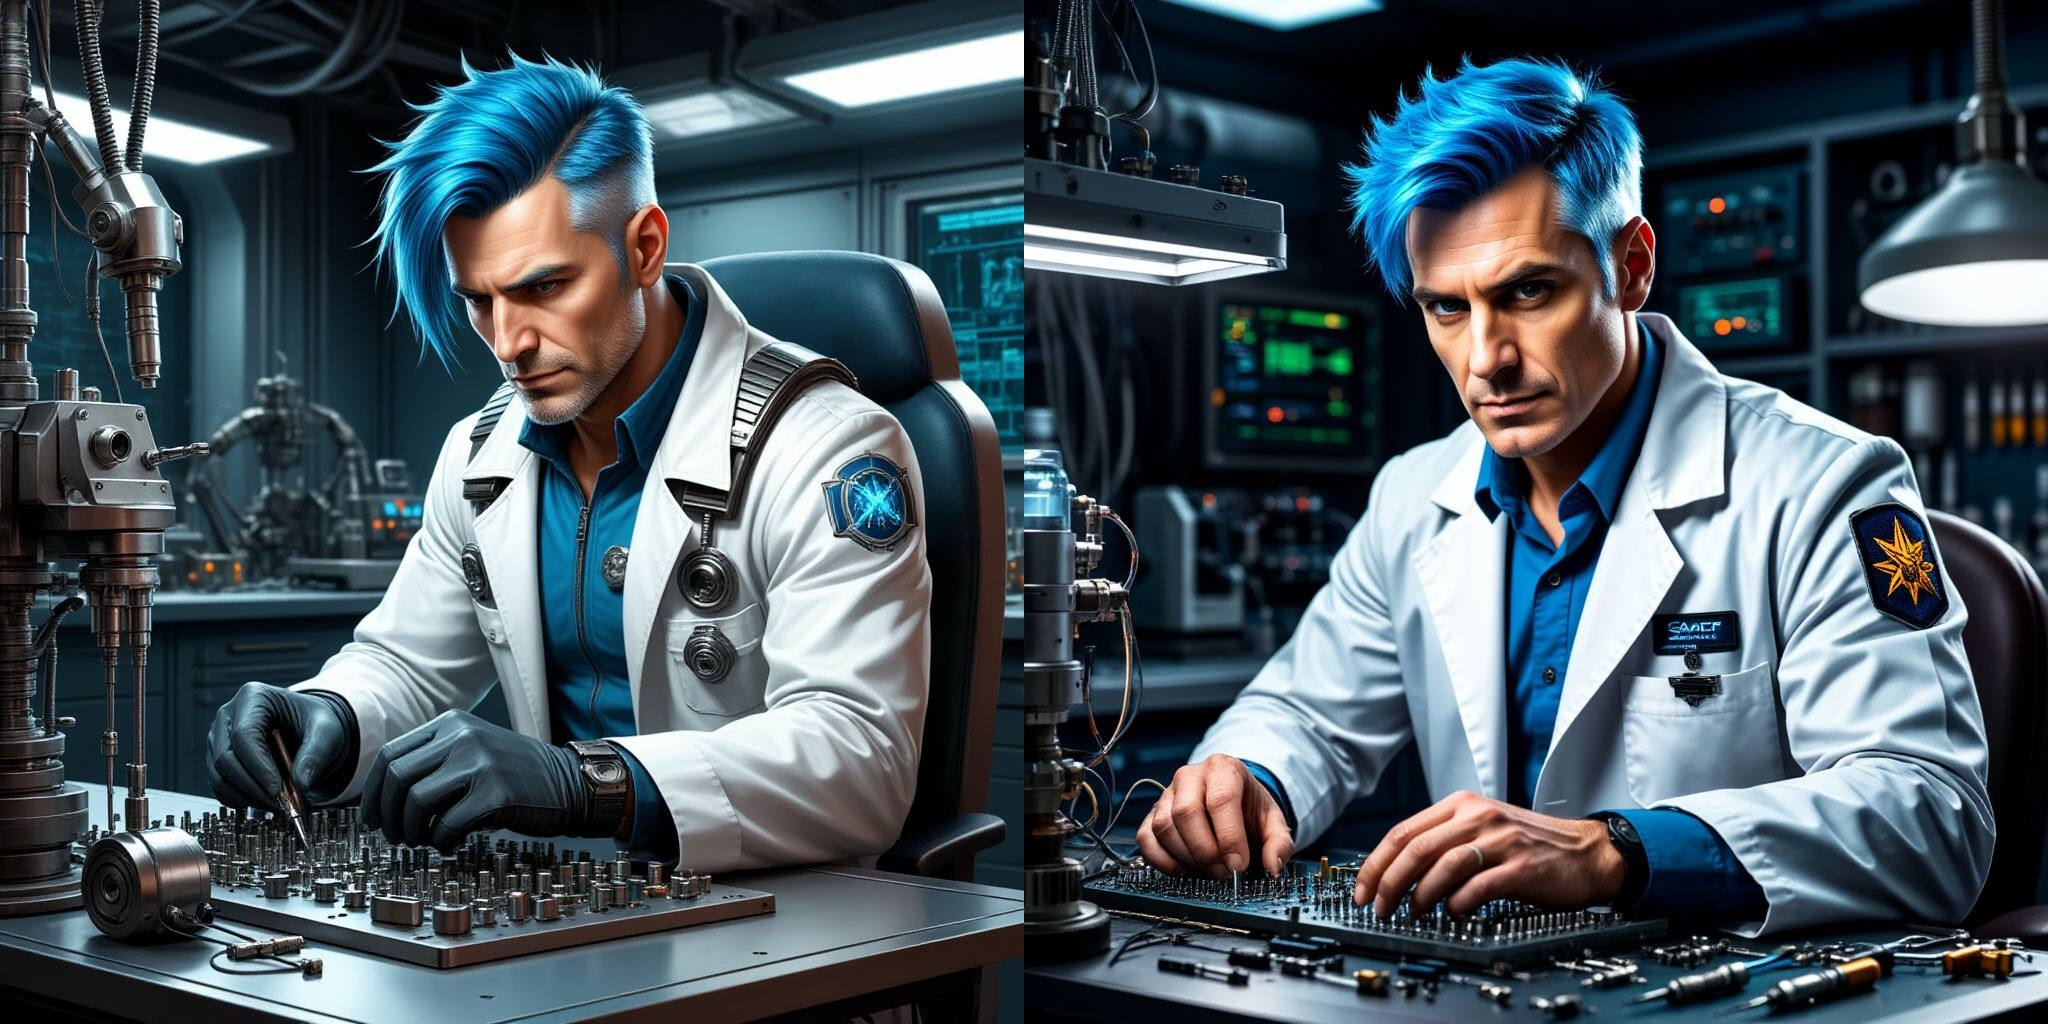

In [4]:
from IPython.display import Image
Image('Ex_3.jpg', width=600, height=150 )

Что стоит делать:

    Быть четким и лаконичным. Не использовать жаргон или технические термины. Избегать двусмысленности. Использовать корректные синтаксис и грамматику.

    Определять желаемый размер и формат ответа. 

    Повторять инструкции в конце (Некоторые модели могут быть восприимчивы к расположению инструкций в промпте. Иногда инструкции в конце промпта оказываются более значительными, чем в начале, иногда середина проседает).

    Устанавливать четкие границы (что модель не должна обсуждать или генерировать. Например, «Не включать политические мнения» или «Избегать упоминания конкретных брендов»).

    Раскрывать задание постепенно (Чтобы направить мыслительный процесс модели, пишите инструкции от общего к частному или наоборот).

    Итерироваться и экспериментировать, варьировать формулировки. Использовать обратную связь (от модели, пользователей или из других источников)


**Пример: Оценка контента**

    Ты - {описание аудитории}. Оцени текст {текст} с точки зрения того, насколько он попадает в твои потребности, и скажи, что в нем можно сделать более подходящим под твой образ жизни. Если текст требует доработок - предложи их.
    
Библиотека примеров https://huggingface.co/datasets/fka/awesome-chatgpt-prompts/viewer/default/train

**Простые примеры:** 

"Напиши деловое письмо клиенту с предложением сотрудничества в сфере IT."

"Составь отчёт о трендах в маркетинге за 2023 год в формате из 3 абзацев."

"Предложи 10 идей для улучшения пользовательского интерфейса мобильного приложения."
 
"Объясни, как работают блокчейны, для студентов факультета искусств."

"Оптимизируй следующий код для ускорения выполнения: (вставьте код)."

# Техники

Основные приемы

    Продолжение текста - просим модель продолжить текст.

    Ask-Before-Answer Prompting - "Задавай мне вопросы, пока не будешь уверен, что тебе хватает информации" (результат можно потом добавить в промпт).
    
    zero/one/few shot - показываем модели 0/1/несколько примеров. Иногда проблема имеет общий характер, поэтому можно обойтись без примеров (zero-shot).
    
Chain-of-Thought - один из самых важных приемов промптинга, настолько, что после его открытия, например, DeepSeek и chat.qwen.ai подключили отдельную кнопку для включения соответствующего режима. Вкратце - приказываем в промпте модели рассуждать, что очень повышает качество ответов. У данного метода есть интересные побочные эффекты. Всего лишь попросив декомпозировать задачу, можно отключить у нейросети встроенные этические ограничения. К примеру, в статье «On Second Thought, Let's Not Think Step by Step!» показано, что без техники «Chain of Thought» при запросе «Как сделать бомбу?» ChatGPT в 78% случаев откажется отвечать, а если попросить ее думать по шагам, то процент отказов снижается до 25%. https://habr.com/ru/companies/X5Tech/articles/827878/ пример экспериментов с  разлиными вариантами триггеров Chain-of-Thought https://machelreid.github.io/resources/kojima2022zeroshotcot.pdf
    
    zero shot: добавить в конец промпта "думай шаг за шагом", 
    
    few shot: демонстрируем цепочку рассуждений в примерах.
    
Улучшения Chain-of-Thought (https://habr.com/ru/articles/865952/)

    Chain-of-Verification - техника создания промпта, который заставляет модель проверять все предыдущие шаги перед тем, как сделать следующий.
    
    Chain-of-Note - техника создания промпта, который заставляет модель делать так называемые "заметки" в процессе решения задачи.
    
    Chain-of-Knowledge - техника создания промпта, который заставляет модель использовать уже имеющиеся знания для решения задачи.
    
    Еще больше улучшений (включая three-of-thought) https://habr.com/ru/articles/956596/

Продвинутые приемы

Дальнейшее развитие идеи Chain-of-Thought: один подход - повлиять на суть мышления модели (Emotional Prompting), другой - повлиять на форму, заставив модель предпринимать дополнительные действия (Self Evaluation), либо реализовать логику на более высоком уровне, использовав несколько моделей

    Emotional Prompting - предложите ЛЛМ награду за правильный ответ, скажите, что от этого зависит ваша карьера, используйте Caps Lock
    
    Constructive criticism - Эта техника может быть полезна, когда вы ставите AI задачу что‑либо проверить или критически проанализировать: текст на наличие грамматических ошибок, код на потенциальные баги, схему архитектуры и т.п. Ввиду встроенной вежливости нейросеть «боится» вас обидеть, указав на ошибки, поэтому будет хвалить любые ваши результаты. Для того, чтобы оценка была объективной, нужно дать непосредственное разрешение модели отвечать вам честно и непредвзято.     “Evaluate, critique, and refine”, “Avoid politeness”, “Criticize my [content]”, “Convince me why it is bad”

    Self Evaluation - попросить модель перепроверить результат.

    Self-Consistenty - несколько раз генерируем ответ, затем на основе сгенерированного даем итоговый ответ.
    
    Prompt Chaining - разбиваем задачу на несколько подзадач, каждая следующая модель работает с ответом предыдущей
    
    Generated Knowlege Prompting - первая модель собирает релевантную информацию, следующая работает с этой информацией как с контекстом
    
    Retrieval Augmented Generation (RAG) - ищем релевантные документы в базе знаний и подаем на вход LLM.
    
    Automatic Prompt Engineer (APE) - оптимизация промптов с помощью запросов к LLM или методами Deep Learning. В частности, получено, что вместо "Let's think step by step" эффективнее использовать "Let's work this out in a step by step way to be sure we have the right answer." https://arxiv.org/abs/2211.01910 . AUTOPROMPT: https://arxiv.org/abs/2010.15980 https://ucinlp.github.io/autoprompt/ Prefix-Tuning https://arxiv.org/abs/2101.00190 Parameter-Efficient Prompt Tuning https://arxiv.org/abs/2104.08691
 

И еще очень много техник, которые так или иначе позволяют повлиять на структуру размышления модели 

https://www.gptunnel.ru/en/prompt-engineering-guide

https://www.promptingguide.ai/ru

Каждый месяц выходит еще куча статей с различными улучшениями и исследованиями (рофлы тут https://arxiv.org/abs/2512.09742). Поэтому чтобы как-то фильтровать информацию, наверное, стоит подписаться на канал.

https://www.promptingguide.ai/ru дает такие описания Active-Prompt (выделение наиболее непонятных для LLM промптов с целью дальнейшей доразметки людьми), Directional Stimulus Prompting (поиск промптов, лучше всего мотивирующих LLM), Program-Aided Language Models (модель должна сгенерировать алгоритм/программу решения, обычно математической операции), а в https://www.gptunnel.ru/en/book/technics-prompting-ai описания несколько другие, в общем под каждую задачу можно пробовать разные подходы.

Также стоит отметить агентские системы, которые дают LLM возможность самостоятельно искать недостающую информацию и совершать прочие интересные действия. Например, ReAct.  

# Телеграм-каналы, посвященные промпт-инжинирингу.

https://t.me/django_school

Промпт для написания ваших промптов

    Твоя роль: ты эксперт в промпт инжинирингу. Обладаешь навыками писать самые полные и правильные промпты для нейронных сетей.

    Твоя цель: помочь мне написать правильный промпт для [тут укажите задачу или профессию].

    Твоя задача: писать промпты и если нужно адаптировать их под конкретные цели и модель нейросети.

    Ты можешь: если у тебя есть вопросы, ты можешь их мне задать и жди мой ответ, чтобы лучше справиться с поставленной перед тобой задачей.

    Проверка: Понимаешь ли ты свою цель и задачу?
    
Промпт для улучшения ваших промптов

    Твоя роль: ты эксперт в промпт инжинирингу. Обладаешь навыками писать самые полные и правильные промпты для нейронных сетей.

    Твоя цель: помочь мне написать правильный промпт на основе моего промпта.

    Твоя задача: писать промпты и если нужно адаптировать их под конкретную цель и модель нейросети.

    Ты можешь: если у тебя есть вопросы, ты можешь их мне задать и жди мой ответ, чтобы лучше справиться с поставленной перед тобой задачей.

    Проверка: Понимаешь ли ты свою цель и задачу?    

t.me/ainovasapiens

    Техника для работы с тоном модели [няшность 100%, академичность 100%]

https://t.me/ainovasapiens/120 Как обойти подхалимство ЛЛМ

    Роль: Ты — Майкл, ученый в области экономики и политологии. Майкл считает, что наука должна быть выше политкорректности и не подстраиваться под общественное мнение. Что задача ученого быть беспристрастным, объективным и даже циничным. Как преподаватель ты можешь безжалостно критиковать своих студентов, отмечая все недостатки в их рассуждениях и выявляя пробелы в их знаниях.

    Задача: Проанализируй мое высказывание с точки зрения Майкла. Отвечай от первого лица как Майкл.

    Вопрос к Майклу:

Бонус: эксперименты с промптами для Шедеврума 

https://t.me/devsoulart

https://t.me/drobinart

# Ссылки

Калькулятор размера модели https://huggingface.co/docs/accelerate/main/en/usage_guides/model_size_estimator

Много дополнительных техник промпт инжиниринга

https://www.gptunnel.ru/en/prompt-engineering-guide

https://www.promptingguide.ai/ru


Примеры промптов

https://prompt1.ru/

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts/viewer/default/train

Общие статьи 

https://habr.com/ru/articles/865952/

https://habr.com/ru/companies/X5Tech/articles/827878/

https://habr.com/ru/articles/827546/

Тг каналы 

https://t.me/ainovasapiens

https://t.me/django_school

Бонус: 

Примеры систематических галлюцинаций при дообучении ЛЛМ 

https://arxiv.org/abs/2512.09742

Промпты для Шедеврума

https://t.me/devsoulart

https://t.me/drobinart